# 손바닥 sEMG 사용자 식별: 1주차 실습

**문제 정의와 데이터 이해** · 실데이터 기반 실행 결과

첨부 강의자료의 1주차 5단계에 맞춘 실습이다. CNN 학습은 2주차 범위이며, 여기서는 실제 파일 구조와 파형을 확인한다.

- 연구: Shin, Kim & Choi (2026), [논문 원문](https://www.nature.com/articles/s41598-026-46294-3)
- 데이터: [저자 공개 저장소](https://github.com/sea3551/palm-sEMG-doorknob-filtered), CC BY 4.0, © 2025 Yeonjung Shin
- 과제 기준: `Step1_1주차_강의와실습.pdf` 9~17쪽. 첫 다섯 선행연구 행은 강의자료 14쪽과 논문 저자 원고 Table 1을 대조했다.
- 재실행: VS Code에서 커널을 `.venv/Scripts/python.exe`로 선택한 후 **Run All**.

## 문제 정의
입력은 문손잡이를 잡고 돌릴 때 얻은 손바닥 2채널 근전도이며, 출력은 등록자 A~E 중 한 명이다. 미등록자 거절을 평가하는 문제가 아닌 **closed-set 5-class identification**이다. 연구의 보고 정확도 94.00%는 이번 노트북에서 재학습한 결과가 아니다.


## 1. 환경 확인
아래 셀은 설치 버전과 Python 경로를 실제 출력한다. 출력 화면을 환경 확인 증빙으로 사용할 수 있다. 1주차 분석 패키지를 설치했고, 통합 저장소 루트의 `requirements.txt`에 다음 주 CNN용 `torch`와 `torchvision`을 함께 명시했다.

In [1]:
from pathlib import Path
import sys, importlib.metadata
import numpy as np
import pandas as pd
import scipy, sklearn, pywt
from IPython.display import display, Image, Markdown
from analyze_week1 import main, ROOT, OUT, DATA, load_trial
print('Python:', sys.version)
print('Interpreter:', Path(sys.executable).name)
packages = ['numpy', 'scipy', 'matplotlib', 'pandas', 'scikit-learn', 'PyWavelets', 'ipykernel']
display(pd.DataFrame({'package': packages, 'version': [importlib.metadata.version(p) for p in packages]}))
print('OK: all Week 1 analysis imports succeeded')

Python: 3.12.14 (main, Aug 25 2026, 14:01:42) [MSC v.1944 64 bit (AMD64)]
Interpreter: python.exe


,package,version
0,numpy,2.5.3
1,scipy,1.18.1
2,matplotlib,3.11.2
3,pandas,3.0.5
4,scikit-learn,1.9.1
5,PyWavelets,1.10.0
6,ipykernel,7.3.0


OK: all Week 1 analysis imports succeeded


## 2. 데이터 확보 및 구조
저장소 ZIP을 내려받아 원본 README와 LICENSE를 보존했다. 프로젝트 기준 실제 CSV 위치는 `data/data/A`~`data/data/E`이다. 데이터 파일 250개와 README·LICENSE 2개를 구별한다.

CSV 첫 행은 `Comp Ch 3,Comp Ch 4` 헤더이며, 각각 APB와 ADM 채널이다. 헤더를 데이터로 읽거나 첫 수치행을 잘못 버리지 않도록 `pandas.read_csv`로 읽는다. 원본 CSV는 변경하지 않는다.


In [2]:
meta, summary, phases, environment = main()
print('CSV count:', len(meta))
print('Subjects:', ', '.join(sorted(meta.subject.unique())))
print('Example:', meta.iloc[0]['file'])
x = load_trial(ROOT / meta.iloc[0]['file'])
print('Shape:', x.shape, '| Range:', x.min(), '~', x.max())
display(pd.DataFrame(x[:5], columns=['CH1 / APB', 'CH2 / ADM']))

OK: 250 trials, 5 subjects, 3000 samples x 2 channels, all finite
         trials  samples  channels  duration_s   minimum   maximum
subject                                                           
A            50     3000         2         3.0 -3.536560  4.339420
B            50     3000         2         3.0 -1.385330  1.672260
C            50     3000         2         3.0 -0.663993  0.741765
D            50     3000         2         3.0 -1.249150  1.276180
E            50     3000         2         3.0 -2.110370  2.018690

First-trial RMS: phase              Grasp   Rotate     Stop
subject channel                           
A       1        0.46983  0.69319  0.27721
        2        0.03639  0.05896  0.03840
B       1        0.04790  0.11986  0.06394
        2        0.03445  0.02441  0.01583
C       1        0.04702  0.08972  0.05757
        2        0.03033  0.05742  0.03799
D       1        0.17011  0.07201  0.05992
        2        0.13507  0.05581  0.02731
E       1        

,CH1 / APB,CH2 / ADM
0,-0.027051,-0.010520
1,-0.014940,-0.012154
2,-0.002137,-0.013285
3,0.008692,-0.001895
4,0.024088,0.011056


## 3. 데이터 요약
샘플링 주파수 1,000 Hz는 저자 README의 메타데이터이며 CSV 자체에는 시간 열이 없다. 3,000개 샘플은 3초 분량이다. 아래 표의 범위는 피험자별 50개 파일 전체에서 계산한다. 채널 단위의 물리적 보정 정보는 확인되지 않아 그래프에 `CSV units`로 표기한다.

In [3]:
display(summary)
assert len(meta) == 250
assert (summary.trials == 50).all()
assert (meta.samples == 3000).all() and (meta.channels == 2).all()
print('All files passed: shape, numeric values, finite values, subject counts.')
print('Global range:', meta.minimum.min(), '~', meta.maximum.max())
print('Identical file hashes:', int(meta.sha256.duplicated().sum()))

,trials,samples,channels,duration_s,minimum,maximum
subject,,,,,,
A,50,3000,2,3.0,-3.536560,4.339420
B,50,3000,2,3.0,-1.385330,1.672260
C,50,3000,2,3.0,-0.663993,0.741765
D,50,3000,2,3.0,-1.249150,1.276180
E,50,3000,2,3.0,-2.110370,2.018690


All files passed: shape, numeric values, finite values, subject counts.
Global range: -3.53656 ~ 4.33942
Identical file hashes: 1


### 전처리 상태
저자 README는 60 Hz 노치 및 20~500 Hz 대역통과 필터를 적용했다고 설명한다. 이번 실습은 공개된 **필터링 후 신호**를 그대로 관찰한다. 음수와 1보다 큰 값이 존재하므로 공개 파일은 전체가 0~1 범위로 정규화된 상태가 아니다. 값이 우연히 0~1 안에 있다는 이유만으로 정규화를 단정할 수도 없다.

향후 필터 구현 시 1,000 Hz의 나이퀴스트 주파수는 500 Hz이므로 디지털 필터의 상한 500 Hz를 그대로 넣는 설정은 별도 검토가 필요하다. 이미 필터링된 공개 데이터로 원시 신호와의 필터 전후 비교를 할 수는 없다.


## 4. 신호 시각화
각 피험자의 **1번 시행**을 고정 선택하여 A, B, C를 비교한다. 첫 그림은 공통 y축으로 진폭을 비교하고, 두 번째 그림은 패널별 y축으로 작은 신호의 형태를 확인한다. 두 번째 그림의 높이를 서로 직접 비교하면 안 된다. `Grasp`=파지(0~1초), `Rotate`=회전(1~2초), `Stop`=정지(2~3초)이다. 경계는 실험 절차를 바탕으로 표시한 것이며 CSV의 이벤트 마커로 검증한 시점은 아니다.

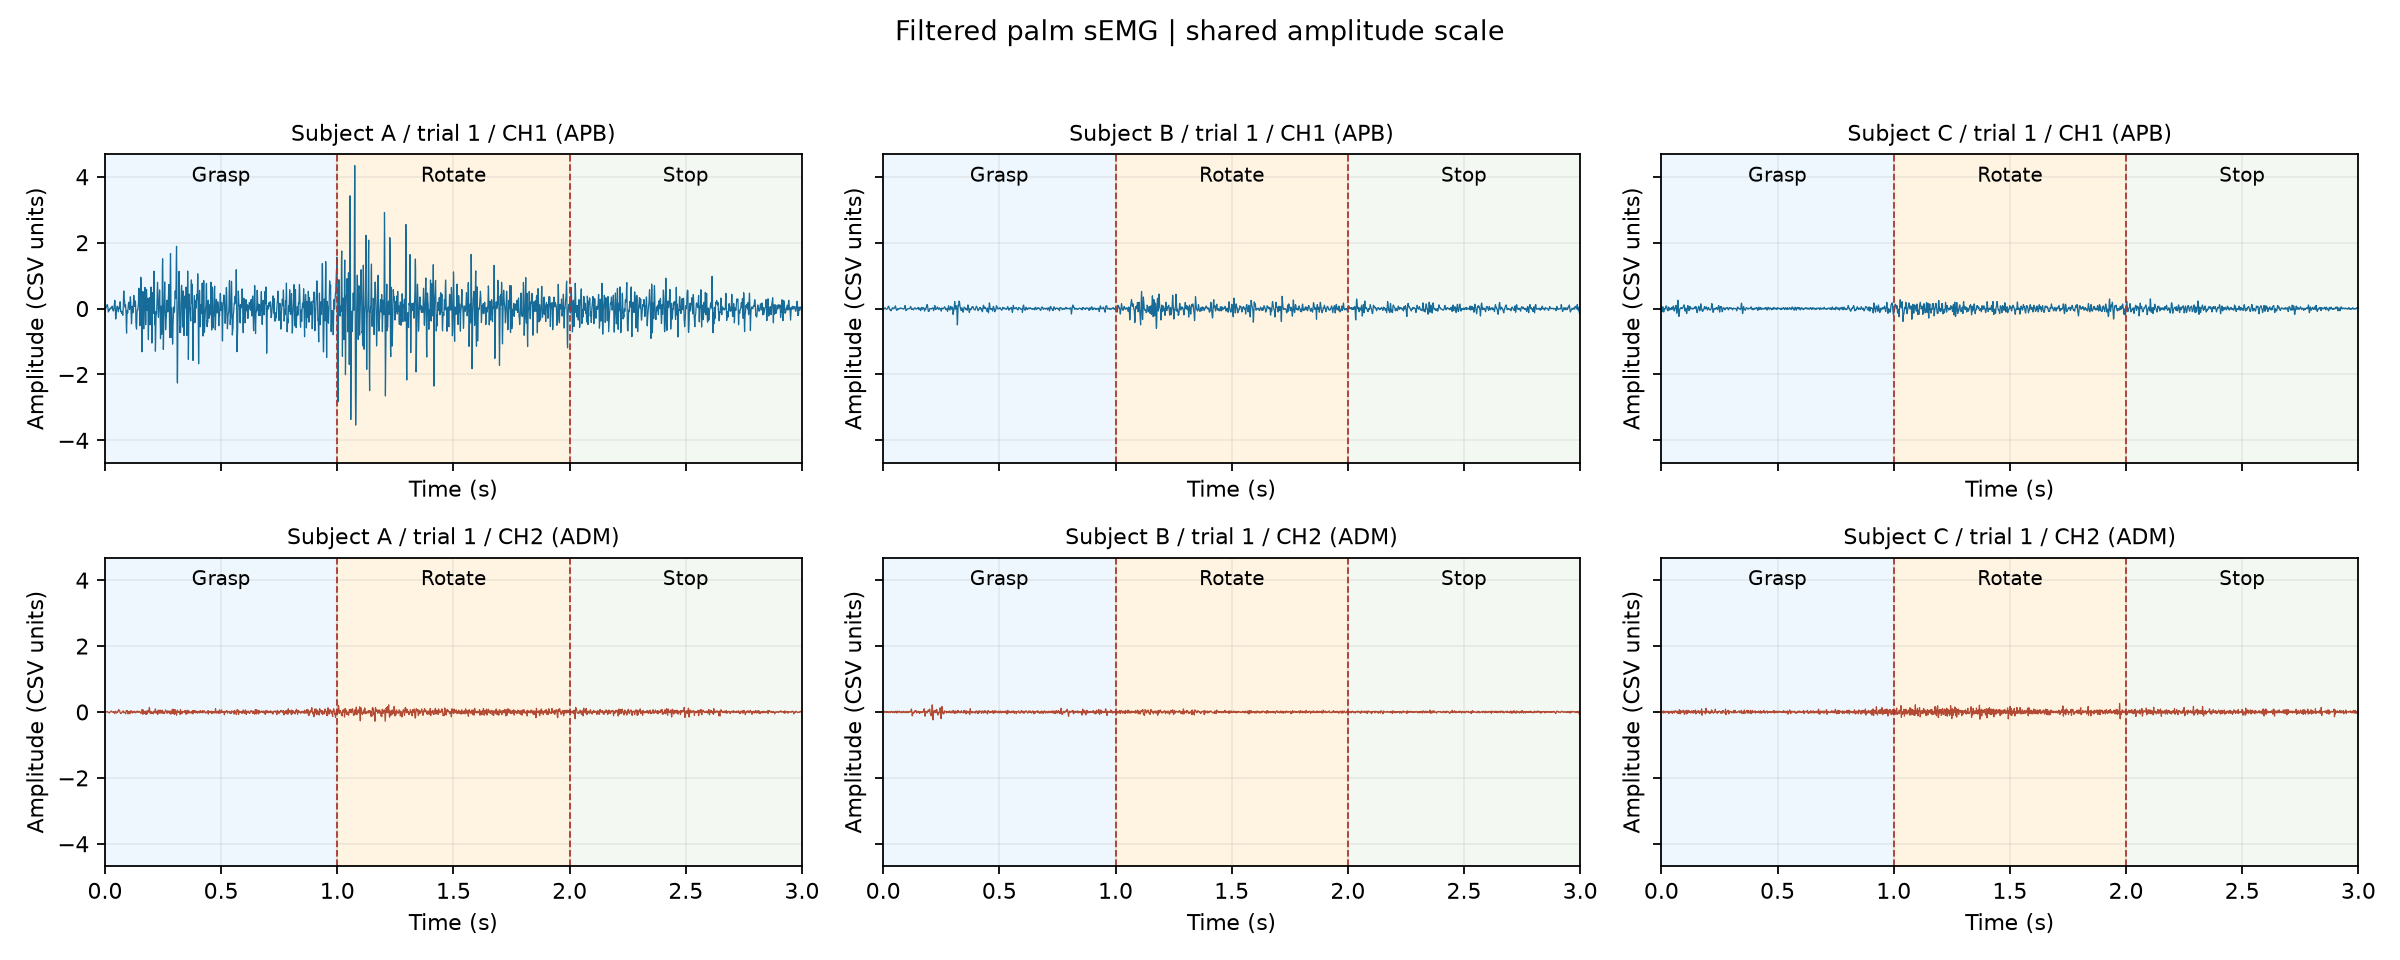

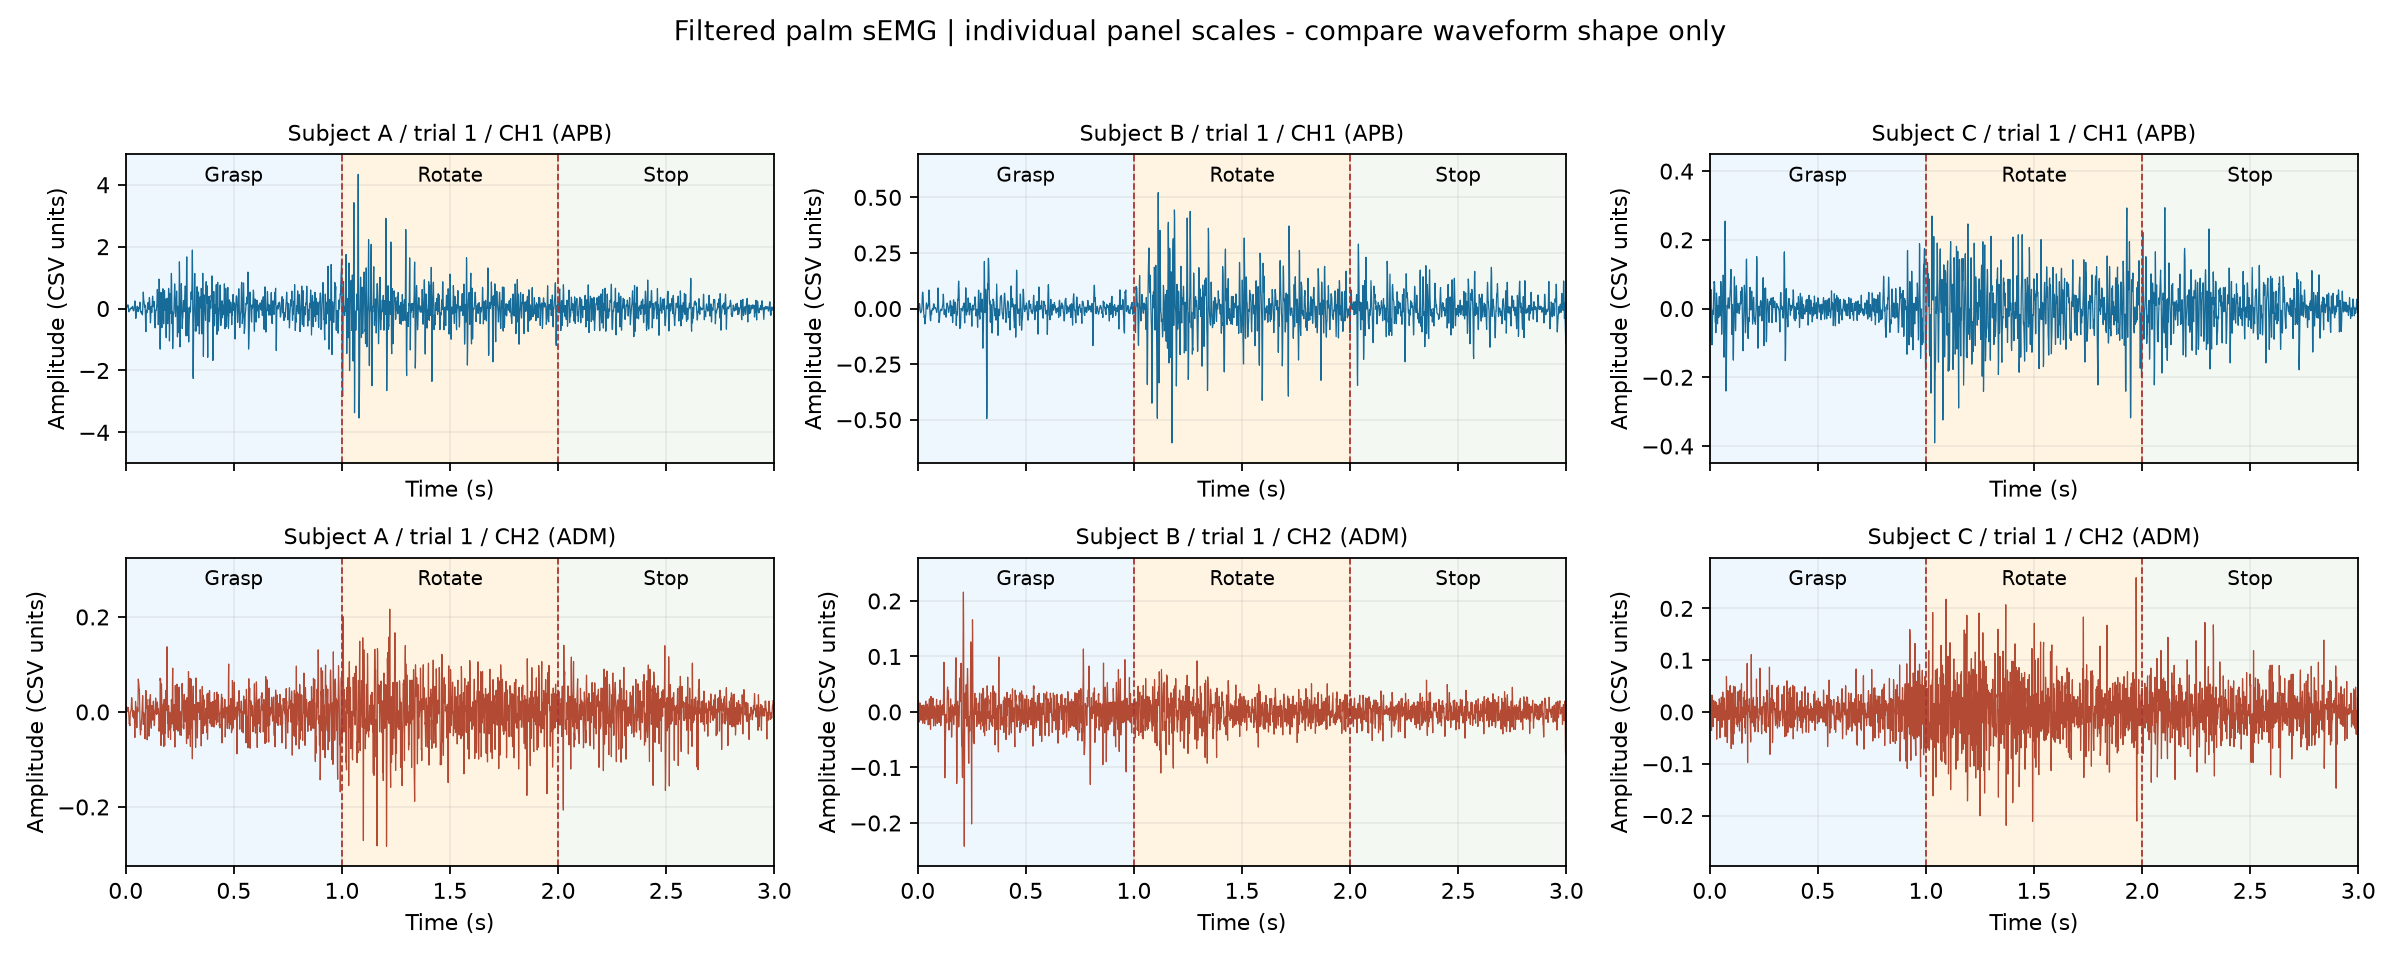

In [4]:
display(Image(filename=str(OUT / 'signals_ABC.png')))
display(Image(filename=str(OUT / 'signals_ABC_detail.png')))

### 관찰을 수치로 확인
RMS = sqrt(mean(x²))는 구간별 신호 크기를 요약한다. 세 구간 중 어느 구간이 큰지 확인하는 보조 지표이며 식별 정확도가 아니다.

In [5]:
rms = phases[(phases.trial == 1) & phases.subject.isin(['A','B','C'])].pivot(index=['subject','channel'], columns='phase', values='rms')[['Grasp','Rotate','Stop']]
display(rms.round(5))
notes = [
    f"A의 첫 시행에서는 회전 구간 채널 1 RMS가 {rms.loc[('A',1),'Rotate']:.4f}이고 채널 2는 {rms.loc[('A',2),'Rotate']:.4f}로, 같은 동작에서도 두 채널의 신호 크기가 달랐다.",
    f"B의 첫 시행 채널 2에서는 파지 RMS({rms.loc[('B',2),'Grasp']:.4f})가 회전 RMS({rms.loc[('B',2),'Rotate']:.4f})보다 커서, 회전 구간이 항상 가장 크지는 않았다.",
    f"첫 시행의 회전 구간 채널 1 RMS는 A {rms.loc[('A',1),'Rotate']:.4f}, B {rms.loc[('B',1),'Rotate']:.4f}, C {rms.loc[('C',1),'Rotate']:.4f}로 차이가 났다. 공통 축에서 A의 큰 진폭이 두드러졌지만 이것만으로 식별 성능을 판단할 수는 없다."
]
text = '\n'.join(f'{i+1}. {s}' for i,s in enumerate(notes))
display(Markdown('### 관찰 메모 3가지\n' + text))
(OUT / 'observations.md').write_text('# 관찰 메모\n\n'+text+'\n\n각 메모는 1번 시행에 한정된다. 모든 시행이나 다른 날의 개인 특성으로 일반화하지 않는다.\n', encoding='utf-8')

phase              Grasp   Rotate     Stop
subject channel                           
A       1        0.46983  0.69319  0.27721
        2        0.03639  0.05896  0.03840
B       1        0.04790  0.11986  0.06394
        2        0.03445  0.02441  0.01583
C       1        0.04702  0.08972  0.05757
        2        0.03033  0.05742  0.03799

### 관찰 메모 3가지
1. A의 첫 시행에서는 회전 구간 채널 1 RMS가 0.6932이고 채널 2는 0.0590로, 같은 동작에서도 두 채널의 신호 크기가 달랐다.
2. B의 첫 시행 채널 2에서는 파지 RMS(0.0345)가 회전 RMS(0.0244)보다 커서, 회전 구간이 항상 가장 크지는 않았다.
3. 첫 시행의 회전 구간 채널 1 RMS는 A 0.6932, B 0.1199, C 0.0897로 차이가 났다. 공통 축에서 A의 큰 진폭이 두드러졌지만 이것만으로 식별 성능을 판단할 수는 없다.

331

관찰 메모는 위 실행 결과에서 자동으로 작성한 초안이다. 파형을 직접 확인하고 본인의 표현으로 다듬어 제출할 수 있다. 회전 구간이 항상 최대여야 한다는 가정을 적용해 결과를 고치지 않는다. 서로 다른 진폭만으로 사람을 안정적으로 식별할 수 있다고 결론내릴 수 없다.

## 5. 선행연구 비교표
앞의 다섯 행은 **[논문 저자 원고 Table 1 (PDF 6쪽)](https://www.nature.com/articles/s41598-026-46294-3_reference.pdf)**을 직접 확인하고 강의자료 14쪽과 대조하여 재작성했다. 원고는 Article in Press 버전이다. 마지막 행은 출판 논문의 본문·초록에서 확인했다. 원표의 up to는 최대값으로 표기했으며, 강의자료의 ~99.21은 원표에서 최대 99.206으로 제시되어 있다. 개별 선행연구 원문까지 독립 검증한 것은 아니다.

| 연구(대상 논문 참조) | 측정 부위 | 인원 | 채널 | 동작 | 특징 추출 + 모델 | 정확도(%) |
|---|---|---:|---:|---|---|---:|
| Buriro et al. | 손목 | 50 | 8 | 박수치기 | GAN + DNN | 97.94 |
| Fan et al. | 전완 | 80 | 8 | 스마트폰 잠금해제 | Siamese CNN | 92.06 |
| Gursoy et al. | 전완 | 5 | 4 | 손동작 6종 | DWT/EWT/EMD + CNN | 최대 95.62 |
| Kim et al. | 이두·삼두 | 40 | 12 | 손동작 3종 | CQT + CNN | 97.50 |
| Lu et al. | 전완 | 21 | 4 | 손 펴기 | DWT/CWT + CNN | 최대 99.206 |
| Shin, Kim & Choi (대상 논문) | 손바닥 | 5 | 2 | 문손잡이 파지·회전·정지 | CWT + DenseNet161 | 94.00 |

**차이점 두 문장**

1. 이 연구는 손바닥 2채널에서 얻은 문손잡이 조작 신호를 사용하여 일상 동작으로 등록 사용자를 구별한다.
2. 비교 대상과 측정 위치·채널 수·참가자 수 및 평가 조건이 다르므로 정확도 숫자만으로 연구 간 우열을 판단할 수 없다.

표의 모델 정확도는 문헌 보고값이며 이 노트북의 계산 결과가 아니다.


## 제출 및 재현 체크

- [x] 환경 확인 출력과 버전 정보
- [x] 실제 CSV 250개 검사 및 피험자별 요약
- [x] A/B/C의 2채널 파형과 동작 구간 표시
- [x] 관찰 메모 3개 및 구간별 RMS
- [x] 선행연구 표와 대상 논문 행, 차이점 두 문장
- 제출 주소: https://github.com/sungbin25/Deep_Learning_project

통합 제출 설명과 모델 비교는 저장소 루트 README를 참고한다. 산출물에는 데이터 원본의 저작권·라이선스와 출처를 유지했다. 재현 시에는 `output/file_manifest.csv`의 SHA-256으로 사용 데이터와 새 다운로드의 동일성을 비교할 수 있다. 다운로드 대상 main 브랜치는 이후 바뀔 수 있다.

다음 주에는 시행 단위로 학습·평가 데이터를 나눈 뒤 윈도우를 생성하여 같은 시행의 중첩 조각이 양쪽에 들어가는 누수를 피해야 한다.
